### 데이터로드

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pop = pd.read_csv('유동인구.csv', encoding='cp949')
sales = pd.read_csv('추정매출.csv', encoding='cp949')

---

## 2030 유동인구 및 비율 구하기

In [28]:
pop.columns

Index(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수',
       '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수',
       '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수',
       '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
       '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '월요일_유동인구_수', '화요일_유동인구_수',
       '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수'],
      dtype='str')

In [29]:
pd.reset_option("display.float_format")
pop.groupby("기준_년분기_코드")["총_유동인구_수"].mean()

기준_년분기_코드
20191    5.915639e+06
20192    5.712035e+06
20193    5.691381e+06
20194    5.877536e+06
20201    5.909987e+06
20202    5.807712e+06
20203    5.731605e+06
20204    5.684058e+06
20211    5.686915e+06
20212    5.648785e+06
20213    5.551854e+06
20214    5.587123e+06
20221    5.605065e+06
20222    5.647061e+06
20223    5.518538e+06
20224    5.548822e+06
20231    5.574186e+06
20232    5.510750e+06
20233    5.465168e+06
20234    5.530577e+06
20241    5.546684e+06
20242    5.450151e+06
20243    5.392043e+06
20244    5.435259e+06
20251    5.422556e+06
20252    5.370719e+06
20253    5.342689e+06
20254    5.346107e+06
Name: 총_유동인구_수, dtype: float64

기준 년 분기마다 유동인구에서 큰 차이가 없음. 

In [30]:
pop_2025 = pop[pop["기준_년분기_코드"].isin([20251, 20252, 20253, 20254])]

pop_2025 = pop_2025.groupby(
    ["행정동_코드", "행정동_코드_명"]
).agg({
    "총_유동인구_수": "mean",
    "연령대_20_유동인구_수": "mean",
    "연령대_30_유동인구_수": "mean"
}).reset_index()

pop_2025["2030_유동인구"] = (
    pop_2025["연령대_20_유동인구_수"] +
    pop_2025["연령대_30_유동인구_수"]
)

pop_2025["2030_비율"] = (
    pop_2025["2030_유동인구"].astype(float) /
    pop_2025["총_유동인구_수"].astype(float)
)

In [31]:
print(pop_2025["2030_비율"].head(10))

0    0.289174
1    0.356584
2    0.331013
3    0.239898
4    0.199585
5    0.238554
6    0.250856
7    0.325274
8    0.400383
9    0.319850
Name: 2030_비율, dtype: float64


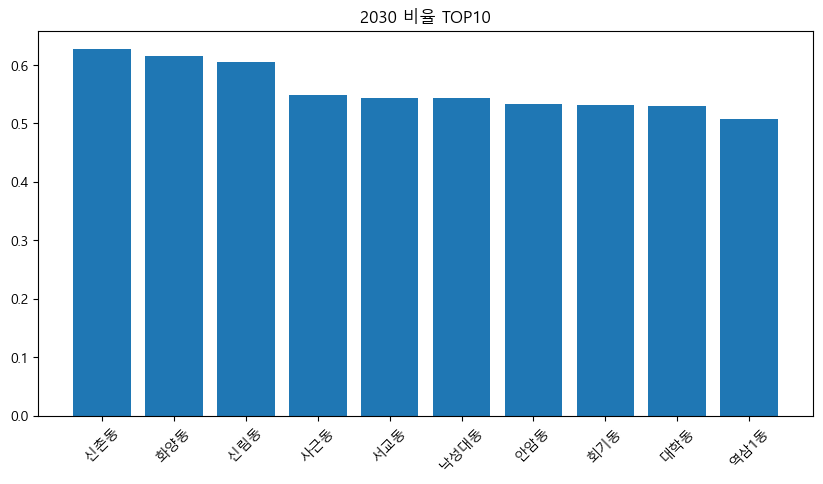

In [32]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
top10 = pop_2025.sort_values(
    "2030_비율",
    ascending=False
).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top10["행정동_코드_명"],
    top10["2030_비율"]
)

plt.xticks(rotation=45)
plt.title("2030 비율 TOP10")
plt.show()

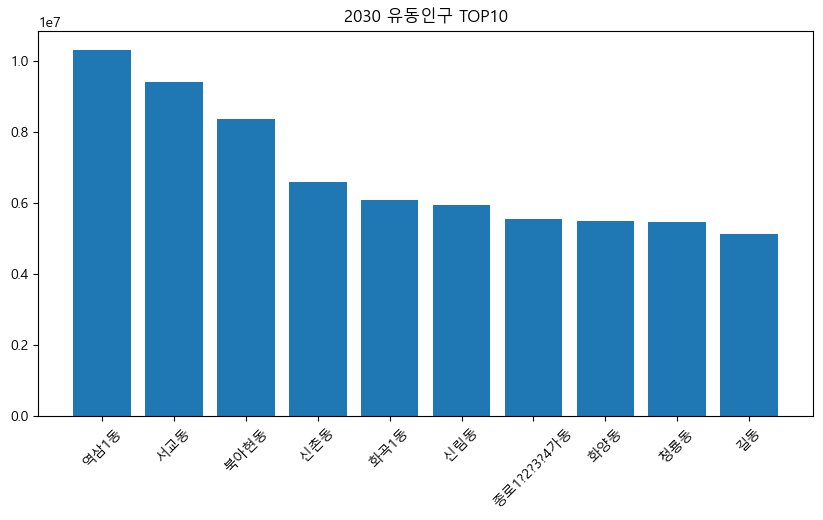

In [33]:
top10 = pop_2025.sort_values(
    "2030_유동인구",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["행정동_코드_명"],
    top10["2030_유동인구"]
)

plt.xticks(rotation=45)
plt.title("2030 유동인구 TOP10")
plt.show()

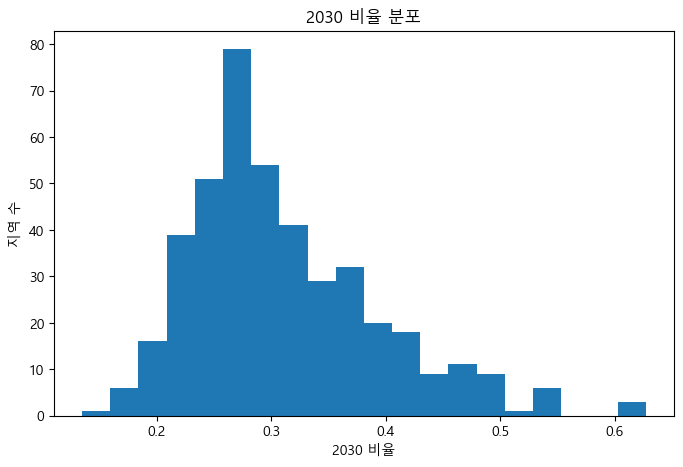

In [34]:
plt.figure(figsize=(8,5))

plt.hist(pop_2025["2030_비율"], bins=20)

plt.title("2030 비율 분포")
plt.xlabel("2030 비율")
plt.ylabel("지역 수")

plt.show()

---

## 추정매출 2030 파생변수 생성

In [35]:
sales.columns

Index(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
       '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액',
       '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액',
       '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액',
       '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
       '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수',
       '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수',
       '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수',
       '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수',
       '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수',
       '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수',
       '연령대_50_매출_건수', '연령대_60_이상_매출_건수'],
      dtype='str')

In [36]:
sales["기준_년분기_코드"].unique()

array([20254, 20253, 20252, 20251])

In [37]:
sales.groupby("기준_년분기_코드")["당월_매출_건수"].mean()

기준_년분기_코드
20251    50539.424329
20252    54695.319698
20253    55708.081635
20254    54358.278921
Name: 당월_매출_건수, dtype: float64

In [38]:
cafe = sales[sales["서비스_업종_코드_명"] == '커피-음료']
cafe.groupby("기준_년분기_코드")["당월_매출_건수"].mean()

기준_년분기_코드
20251    197935.066667
20252    235644.334917
20253    242735.218527
20254    215256.301663
Name: 당월_매출_건수, dtype: float64

In [39]:
cafe["2030_매출건수"] = cafe["연령대_20_매출_건수"] + cafe["연령대_30_매출_건수"]

cafe["총매출건수"] = cafe[
    ["연령대_10_매출_건수",
     "연령대_20_매출_건수",
     "연령대_30_매출_건수",
     "연령대_40_매출_건수",
     "연령대_50_매출_건수",
     "연령대_60_이상_매출_건수"]
].sum(axis=1)

cafe["2030비율"] = cafe["2030_매출건수"] / cafe["총매출건수"]
print(cafe["2030비율"])

40       0.432347
66       0.410393
118      0.475813
169      0.455419
219      0.593142
           ...   
66988    0.178624
67010    0.537094
67031    0.492424
67072    0.536251
67105    0.569158
Name: 2030비율, Length: 1683, dtype: float64


In [40]:
cafe_grouped = cafe.groupby(
    ["행정동_코드", "행정동_코드_명"]
).agg({
    "2030비율": "mean",
    "2030_매출건수": "sum",
    "당월_매출_건수": "sum"
}).reset_index()


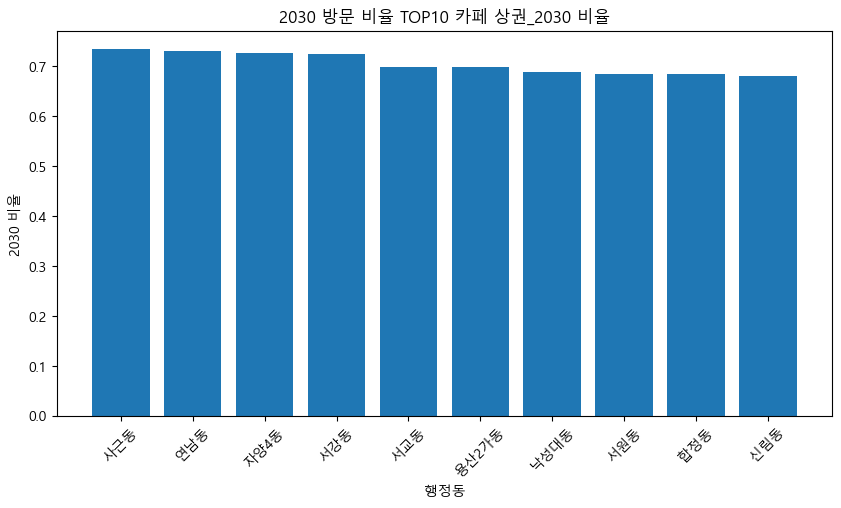

In [41]:
top10 = cafe_grouped.sort_values(
    "2030비율",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["행정동_코드_명"],
    top10["2030비율"]
)

plt.xticks(rotation=45)

plt.title("2030 방문 비율 TOP10 카페 상권_2030 비율")
plt.xlabel("행정동")
plt.ylabel("2030 비율")

plt.show()

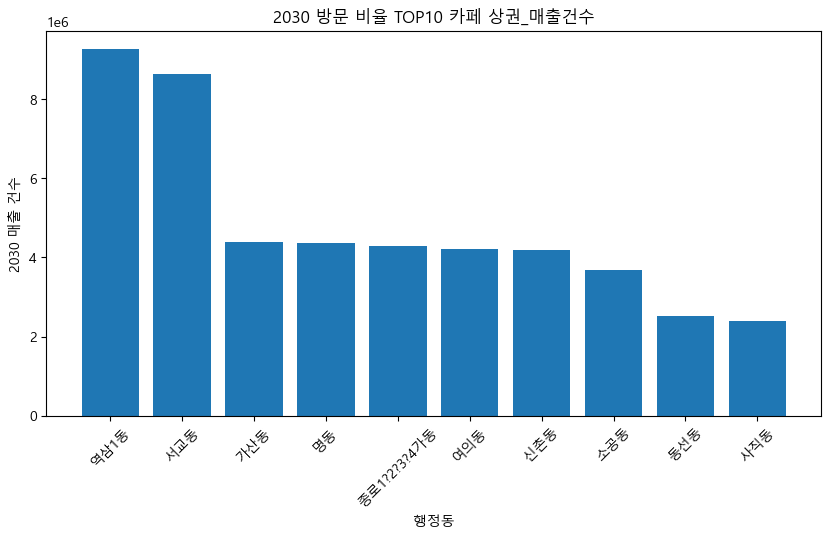

In [42]:
top10 = cafe_grouped.sort_values(
    "2030_매출건수",
    ascending=False
).head(10)
plt.figure(figsize=(10,5))

plt.bar(
    top10["행정동_코드_명"],
    top10["2030_매출건수"]
)

plt.xticks(rotation=45)

plt.title("2030 방문 비율 TOP10 카페 상권_매출건수")
plt.xlabel("행정동")
plt.ylabel("2030 매출 건수")

plt.show()

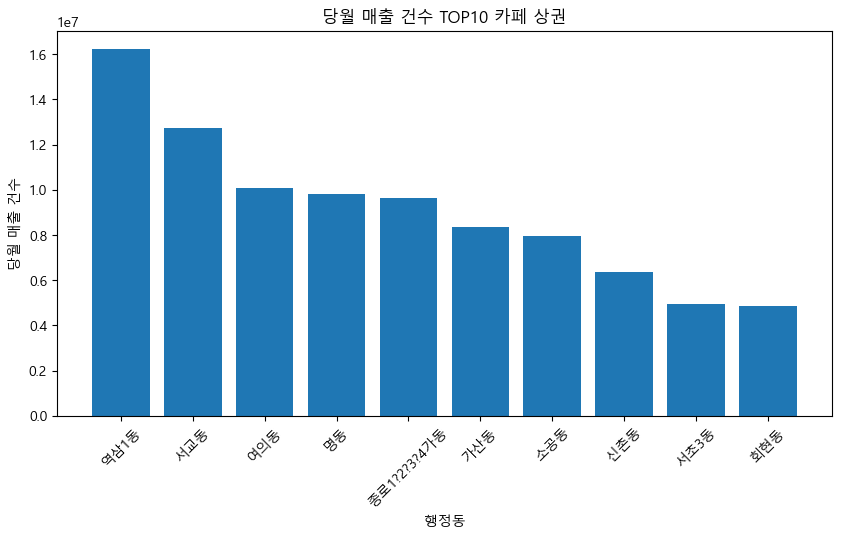

In [43]:
top10 = cafe_grouped.sort_values(
    "당월_매출_건수",
    ascending=False
).head(10)
plt.figure(figsize=(10,5))

plt.bar(
    top10["행정동_코드_명"],
    top10["당월_매출_건수"]
)

plt.xticks(rotation=45)

plt.title("당월 매출 건수 TOP10 카페 상권")
plt.xlabel("행정동")
plt.ylabel("당월 매출 건수")

plt.show()

In [56]:
cafe.columns

Index(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
       '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액',
       '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액',
       '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액',
       '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
       '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수',
       '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수',
       '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수',
       '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수',
       '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수',
       '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수',
       '연령대_50_매출_건수', '연령대_60_이상_매출_건수', '2030_매출건수', '총매출건수', '2030비율',
       '객단가', 'MZ객단가'],
      dtype='str')

In [54]:
# 1. 객단가 (핵심 지표 - 고부가가치 상권 식별)
cafe["객단가"] = cafe["당월_매출_금액"] / cafe["당월_매출_건수"]

# 2. MZ 객단가 (MZ세대만의 구매력)
cafe["MZ객단가"] = cafe["2030_매출건수"] / cafe["당월_매출_건수"] * cafe["객단가"]
# → 일반 객단가보다 높으면 MZ가 더 비싼 메뉴를 시킨다는 의미

In [57]:
time_cols_amount = [
    "시간대_00~06_매출_금액", "시간대_06~11_매출_금액",
    "시간대_11~14_매출_금액", "시간대_14~17_매출_금액",
    "시간대_17~21_매출_금액", "시간대_21~24_매출_금액"
]

# 3. 피크타임 집중도 (매출이 특정 시간에 몰릴수록 운영 전략 필요)
cafe["피크타임_매출비중"] = cafe[time_cols_amount].max(axis=1) / cafe["당월_매출_금액"]

# 4. 오전형 vs 오후형 상권 분류
cafe["오전매출비중"] = (cafe["시간대_06~11_매출_금액"] + cafe["시간대_11~14_매출_금액"]) / cafe["당월_매출_금액"]
cafe["오후매출비중"] = (cafe["시간대_14~17_매출_금액"] + cafe["시간대_17~21_매출_금액"]) / cafe["당월_매출_금액"]

cafe["상권시간유형"] = cafe.apply(
    lambda x: "오전형" if x["오전매출비중"] > x["오후매출비중"] else "오후형", axis=1
)

In [58]:
weekday_cols = ["월요일_매출_금액", "화요일_매출_금액", "수요일_매출_금액",
                "목요일_매출_금액", "금요일_매출_금액"]
weekend_cols = ["토요일_매출_금액", "일요일_매출_금액"]

# 5. 주중/주말 매출 비율
cafe["주중매출비중"] = cafe[weekday_cols].sum(axis=1) / cafe["당월_매출_금액"]
cafe["주말매출비중"] = cafe[weekend_cols].sum(axis=1) / cafe["당월_매출_금액"]

# 6. 주말 프리미엄 (주말 일평균 vs 주중 일평균)
cafe["주말프리미엄"] = (
    cafe[weekend_cols].sum(axis=1) / 2
) / (
    cafe[weekday_cols].sum(axis=1) / 5
)
# → 1 이상이면 주말 장사가 더 잘됨 / 카페는 보통 1.3~1.8 사이

In [63]:
cafe["여성매출비중"] = cafe["여성_매출_금액"] / cafe["당월_매출_금액"]

# 8. MZ 여성 추정 비중 (여성비중 × MZ비율 - 간접 추정)
cafe["MZ여성추정비중"] = cafe["여성매출비중"] * cafe["2030비율"]
# → 감도 높은 타겟 상권 식별용

# 9. 연령 집중도 (특정 연령에 쏠릴수록 리스크/기회 공존)
age_cols = ["연령대_10_매출_금액", "연령대_20_매출_금액", "연령대_30_매출_금액",
            "연령대_40_매출_금액", "연령대_50_매출_금액", "연령대_60_이상_매출_금액"]
cafe["연령집중도"] = cafe[age_cols].max(axis=1) / cafe["당월_매출_금액"]

In [66]:
from sklearn.preprocessing import MinMaxScaler

score_cols = {
    "2030비율": 0.35,
    "객단가": 0.30,
    "주말프리미엄": 0.20,
    "여성매출비중": 0.15
}

scaler = MinMaxScaler()
for col in score_cols:
    cafe[f"{col}_점수"] = scaler.fit_transform(cafe[[col]])

cafe["MZ카페_추천점수"] = sum(
    cafe[f"{col}_점수"] * weight
    for col, weight in score_cols.items()
)

결측치 제거

In [45]:
print(cafe.info())

<class 'pandas.DataFrame'>
Index: 1683 entries, 40 to 67105
Data columns (total 56 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   기준_년분기_코드        1683 non-null   int64  
 1   행정동_코드           1683 non-null   int64  
 2   행정동_코드_명         1683 non-null   str    
 3   서비스_업종_코드        1683 non-null   str    
 4   서비스_업종_코드_명      1683 non-null   str    
 5   당월_매출_금액         1683 non-null   int64  
 6   당월_매출_건수         1683 non-null   int64  
 7   주중_매출_금액         1683 non-null   int64  
 8   주말_매출_금액         1683 non-null   int64  
 9   월요일_매출_금액        1683 non-null   int64  
 10  화요일_매출_금액        1683 non-null   int64  
 11  수요일_매출_금액        1683 non-null   int64  
 12  목요일_매출_금액        1683 non-null   int64  
 13  금요일_매출_금액        1683 non-null   int64  
 14  토요일_매출_금액        1683 non-null   int64  
 15  일요일_매출_금액        1683 non-null   int64  
 16  시간대_00~06_매출_금액  1683 non-null   int64  
 17  시간대_06~11_매출_금액  1683 non-nu

In [46]:
null_pop = pop.isnull().sum()
null_sales = sales.isnull().sum()
print(null_pop[null_pop > 0])
print(null_sales[null_sales > 0])

Series([], dtype: int64)
Series([], dtype: int64)


이상치 확인

In [47]:
cafe["당월_매출_금액"].describe()

count    1.683000e+03
mean     1.738881e+09
std      3.538274e+09
min      2.506870e+05
25%      2.588835e+08
50%      6.707655e+08
75%      1.692560e+09
max      3.864487e+10
Name: 당월_매출_금액, dtype: float64

In [48]:
Q1 = cafe["당월_매출_금액"].quantile(0.25)
Q3 = cafe["당월_매출_금액"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = cafe[(cafe["당월_매출_금액"] < lower) | (cafe["당월_매출_금액"] > upper)]

print(outliers.shape)
outliers.head(15)

(204, 56)


,기준_년분기_코드,행정동_코드,행정동_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,...,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,2030_매출건수,총매출건수,2030비율
788,20254,11710710,잠실6동,CS100010,커피-음료,7178615162,821301,5615842534,1562772628,996040408,...,384884,5059,136230,247212,165881,126904,65171,383442,746457,0.513683
940,20254,11710650,잠실본동,CS100010,커피-음료,3898195176,510987,2514188573,1384006603,424604127,...,250896,13333,107664,140616,101715,82443,44738,248280,490509,0.506168
1050,20254,11710642,문정2동,CS100010,커피-음료,4309965922,654009,3319247495,990718427,616058822,...,265637,2445,79785,208214,150564,93161,48218,287999,582387,0.494515
2142,20254,11680650,역삼2동,CS100010,커피-음료,4537985725,631354,3962154109,575831616,738629299,...,262201,3207,93667,190088,127203,94780,35211,283755,544156,0.521459
2199,20254,11680640,역삼1동,CS100010,커피-음료,35327445013,3866154,27896887489,7430557524,5085948321,...,1719232,54574,898005,1280476,606437,429120,201945,2178481,3470557,0.627704
2251,20254,11680630,대치4동,CS100010,커피-음료,7909476801,903108,6203580788,1705896013,1134859323,...,397168,31790,110320,192264,217403,172716,51388,302584,775881,0.389988
2296,20254,11680610,대치2동,CS100010,커피-음료,6553841417,1035787,5453023935,1100817482,975076986,...,489349,53321,131118,223441,282375,221116,56697,354559,968068,0.366254
2381,20254,11680590,삼성2동,CS100010,커피-음료,5916788323,593778,4992505198,924283125,893250069,...,255451,2799,76699,175626,118263,80029,36970,252325,490386,0.514544
2429,20254,11680580,삼성1동,CS100010,커피-음료,11212244036,1048350,8609864120,2602379916,1441102567,...,487376,6948,166809,331438,211191,115706,60440,498247,892532,0.558240
2533,20254,11680545,압구정동,CS100010,커피-음료,4659798787,471133,3476837865,1182960922,632057422,...,247379,4722,84796,143337,86392,64753,34567,228133,418567,0.545033


In [49]:
print(cafe["당월_매출_금액"].mean())

1738880992.6589425


---

# 데이터 파생변수 심화